# Setup

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os

from astropy.stats import mad_std
from photutils.detection import DAOStarFinder
from photutils.centroids import centroid_2dg
from photutils.aperture import CircularAperture

# Path to your FITS file
current_dir = os.getcwd()  # Get the current working directory
file_path = os.path.join(current_dir, "HATS-38b", "lco_data-20250407-211")

fits_files = [f for f in os.listdir(file_path) if f.endswith(".fits.fz")]


In [2]:
# HDU 0: Empty primary header (no image)
# HDU 1: SCI — this is your science image, compressed (2400×2400, float32)
# HDU 2: CAT — catalog data (a table)
# HDU 3: BPM — bad pixel mask (probably uint8)
# HDU 4: ERR — error image (likely 1σ uncertainties)

file_test = os.path.join(file_path, fits_files[0])

with fits.open(file_test) as hdul:
    hdul.info()  # See structure

    # Loop through HDUs and print out which ones have data
    for i, hdu in enumerate(hdul):
        print(f"HDU {i}: type={type(hdu)}, shape={hdu.data.shape if hdu.data is not None else 'None'}")

Filename: c:\Users\suzan\Documents\ExoClock\HATS-38b\lco_data-20250407-211\cpt0m439-sq39-20250326-0125-e91.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  SCI           1 CompImageHDU    270   (2400, 2400)   float32   
  2  CAT           1 BinTableHDU    127   928R x 40C   [D, D, D, D, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D]   
  3  BPM           1 CompImageHDU      9   (2400, 2400)   uint8   
  4  ERR           1 CompImageHDU      9   (2400, 2400)   float32   
HDU 0: type=<class 'astropy.io.fits.hdu.image.PrimaryHDU'>, shape=None
HDU 1: type=<class 'astropy.io.fits.hdu.compressed.compressed.CompImageHDU'>, shape=(2400, 2400)
HDU 2: type=<class 'astropy.io.fits.hdu.table.BinTableHDU'>, shape=(928,)
HDU 3: type=<class 'astropy.io.fits.hdu.compressed.compressed.CompImageHDU'>, shape=(2400, 2400)
HDU 4: type=<class 'astropy.io.fits.hdu.compresse

# examine files

In [18]:
def plot_image(file_tag = '-0171-'):
    file_name = [f for f in fits_files if file_tag in f][0]
    file_test = os.path.join(file_path, file_name)

    # This shows the image with the 1st–99th percentile stretch — 
    # very typical for astronomical images where you want to reveal faint structure without being blinded by stars.

    try:
        # Create a figure with 1 row and 2 columns of subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

        with fits.open(file_test) as hdul:
            data_sci = hdul['SCI'].data
            data_err = hdul['ERR'].data
            data_bpm = hdul['BPM'].data

        # Check pixel stats
        print("Min:", np.min(data_sci), "Max:", np.max(data_sci), "Mean:", np.mean(data_sci))

        # Apply a percentile-based stretch
        vmin = np.percentile(data_sci, 1)
        vmax = np.percentile(data_sci, 99)

        # plt.imshow(data_sci, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        # plt.colorbar(label='Pixel value')
        # plt.title('Stretched FITS Image')

        cax1 = ax1.imshow(data_sci, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        ax1.set_title('Stretched FITS Image')
        fig.colorbar(cax1, ax=ax1, label='Pixel value')
        # --- plt.show()

        # BAD PIXELS ---------------------------------------
        total_pixels = data_bpm.size
        bad_pixels = np.count_nonzero(data_bpm != 0)

        # Calculate percentage
        bad_percentage = (bad_pixels / total_pixels) * 100
        # --- print(f"Bad pixels: {bad_pixels} / {total_pixels} ({bad_percentage:.2f}%)")

        # View summary stats --------------------------------
        # print(f"SCI mean: {np.mean(data_sci):.2f}, ERR mean: {np.mean(data_err):.2f}")
        # print(f"Typical SNR: {np.mean(data_sci / data_err):.2f}")

        # # Optional: mask where err is 0 or NaN to avoid divide-by-zero
        # import numpy.ma as ma
        # snr = ma.masked_invalid(data_sci / data_err)

        # # Plot SNR image
        # import matplotlib.pyplot as plt
        # plt.imshow(snr, cmap='plasma', origin='lower', vmin=0, vmax=np.percentile(snr.compressed(), 99))
        # plt.colorbar(label='SNR')
        # plt.title('Signal-to-Noise Ratio')
        # plt.show()

        # Estimate background noise (robust)
        bkg_sigma = mad_std(data_sci)

        # Detect stars using DAOStarFinder
        daofind = DAOStarFinder(fwhm=3.0, threshold=5.0 * bkg_sigma)
        sources = daofind(data_sci)

        # Clean result
        if sources is None or len(sources) == 0:
            print("No stars detected.")
        else:
            # Calculate FWHM based on sharpness (this is a rough estimate, but helpful)
            sharpness = sources['sharpness']

            # Simple heuristic: stars with high sharpness => smaller FWHM
            # You could adjust this based on experimental calibration or known star sizes
            fwhm_values = 2.0 / np.abs(sharpness)  # Heuristic relation (adjust as needed)

            # Calculate HWHM (Half Width at Half Maximum)
            hwhm_values = fwhm_values / 2
            print(f'Image {file_name}')
            print(f"Number of stars detected: {len(hwhm_values)}")
            print(f"Median HWHM: {np.median(hwhm_values):.2f} pixels")
            print(f"Max HWHM: {np.max(hwhm_values):.2f} pixels")

            # Optional: histogram of HWHM values
            plt.hist(hwhm_values, bins=20, alpha=0.8, color='mediumseagreen')
            plt.xlabel("Star HWHM (pixels)")
            plt.ylabel("Count")
            plt.title("HWHM Distribution from Detected Stars")
            plt.grid(True, linestyle='--', alpha=0.5)
            # --- plt.show()

        # Display the plots
        plt.tight_layout()  # Adjust the layout to avoid overlap
        plt.show()
    except Exception as e:
        print(f"Error accessing SCI HDU: {e}")


Min: -1975.0878 Max: 52510.957 Mean: 33.10742
Image cpt0m439-sq39-20250326-0171-e91.fits.fz
Number of stars detected: 1047
Median HWHM: 1.98 pixels
Max HWHM: 4.95 pixels


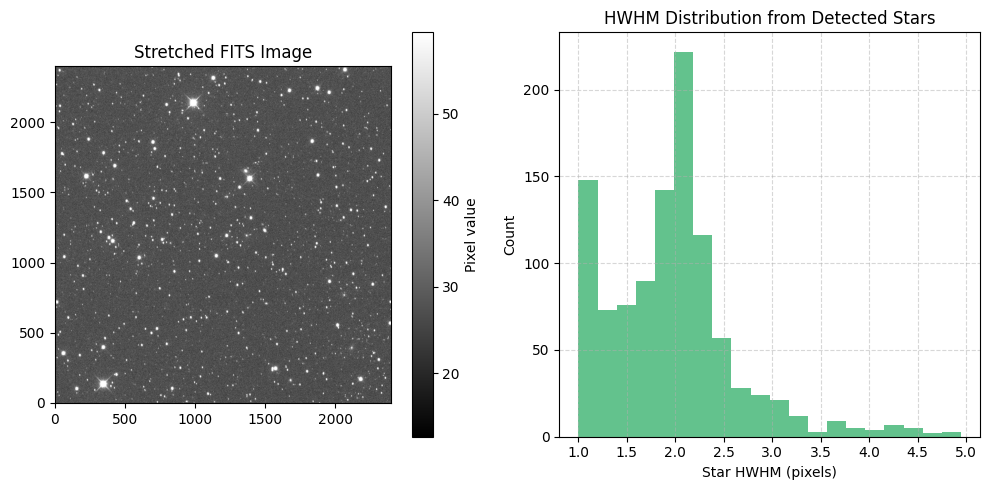

In [26]:
plot_image('-0171-')